In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

# Global seeds
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

In [3]:
from dotenv import load_dotenv
load_dotenv()
dataset_path = os.getenv('DATASET_PATH')

In [4]:
df = pd.read_csv(dataset_path, delimiter=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


STEP 1 -
Get the info abt the dataset and get comfortable with it

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  str    
 2   marital         41194 non-null  str    
 3   education       41194 non-null  str    
 4   default         41195 non-null  str    
 5   housing         41196 non-null  str    
 6   loan            41195 non-null  str    
 7   contact         41195 non-null  str    
 8   month           41196 non-null  str    
 9   day_of_week     41196 non-null  str    
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  str    
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null  float64
 1

# Checking for 'unkown','UNKOWN','Unknown' values

Rows with 'unknown' values

In [6]:
df[df.isin(["unknown", "UNKNOWN", "Unknown"]).any(axis=1)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45.0,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41.0,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
10,41.0,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
15,54.0,retired,married,basic.9y,unknown,yes,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41118,34.0,technician,married,unknown,no,yes,no,cellular,nov,tue,...,2.0,999.0,2.0,failure,-1.1,94.767,-50.8,1.046,4963.6,no
41120,60.0,admin.,married,unknown,no,no,no,cellular,nov,tue,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,no
41122,34.0,technician,married,unknown,no,no,no,cellular,nov,tue,...,3.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.046,4963.6,yes
41135,54.0,technician,married,unknown,no,yes,no,cellular,nov,thu,...,1.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.041,4963.6,no


Total no of 'unknown' values

In [7]:
df.isin(["unknown", "UNKNOWN", "Unknown"]).sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

# Replacing the 'unknwon' values with Nan

In [8]:
exclude_col = 'default'

cols = df.columns.difference([exclude_col])


In [9]:
df[cols] = df[cols].replace(["unknown", "UNKNOWN", "Unknown"],np.nan)

# checking for null values

In [10]:
df.isnull().sum()

age                  4
job                335
marital             85
education         1736
default              4
housing            993
loan               994
contact              4
month                3
day_of_week          3
duration             3
campaign             3
pdays                3
previous             3
poutcome             5
emp.var.rate         3
cons.price.idx       4
cons.conf.idx        3
euribor3m            3
nr.employed          3
y                    3
dtype: int64

Rows where all the col values are null

In [11]:
idx = df[df.isnull().all(axis=1)].index #here axis=1 says => collapse all the col to one col so to form a series which is need for df
print(idx)

Index([41188, 41191, 41197], dtype='int64')


Dropping rows where all the values are null

In [12]:
df.drop(index=idx,inplace=True)
df.reset_index()

,index,age,job,marital,education,default,housing,loan,contact,month,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,1,57.0,services,married,high.school,unknown,no,no,telephone,may,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,2,37.0,services,married,high.school,no,yes,no,telephone,may,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,4,56.0,services,married,high.school,no,no,yes,telephone,may,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41191,41193,94.0,retired,married,professional.course,no,yes,no,cellular,nov,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41192,41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41193,41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41194,41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no


STEP 2 -

Percentage of null rows

In [13]:
per = ((df.isnull().any(axis=1).sum())/len(df))*100
print(round(per,2))

7.16


percentage of null values per coloumn

In [14]:
df.isnull().mean() * 100

age               0.002427
job               0.805903
marital           0.199048
education         4.206719
default           0.002427
housing           2.403146
loan              2.405573
contact           0.002427
month             0.000000
day_of_week       0.000000
duration          0.000000
campaign          0.000000
pdays             0.000000
previous          0.000000
poutcome          0.004855
emp.var.rate      0.000000
cons.price.idx    0.002427
cons.conf.idx     0.000000
euribor3m         0.000000
nr.employed       0.000000
y                 0.000000
dtype: float64

Since  the it has 7.16% null rows it's better to fill the values instead of dropping it

In [15]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


Confirming the filling of null values

In [16]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# Checking for outliers

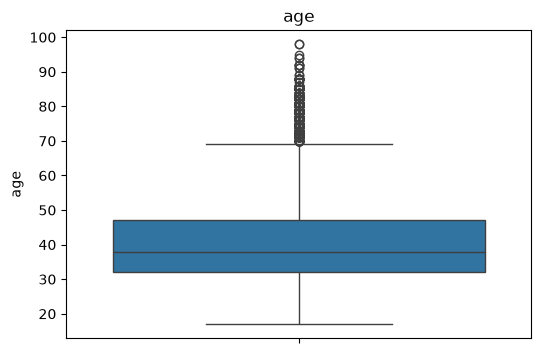

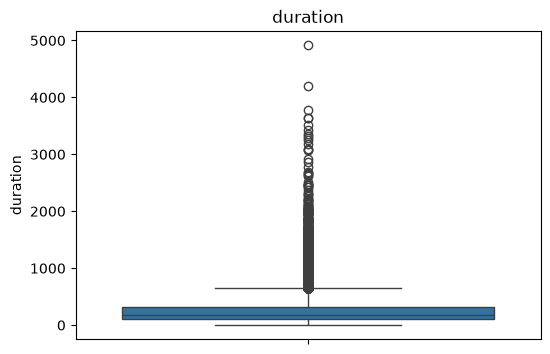

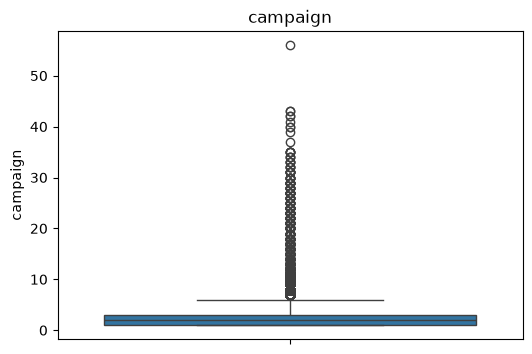

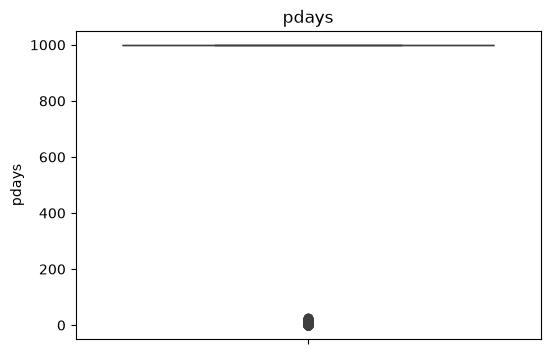

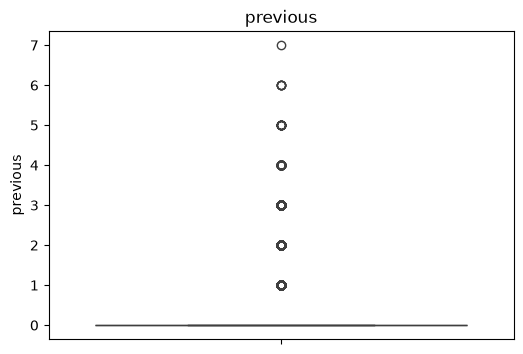

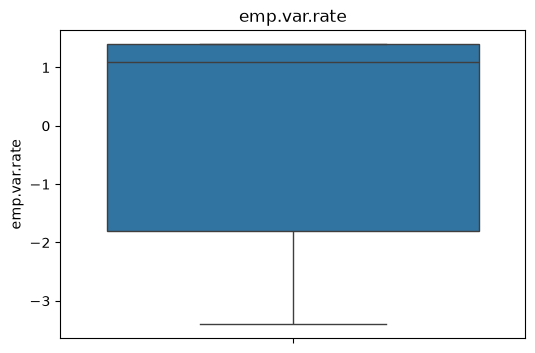

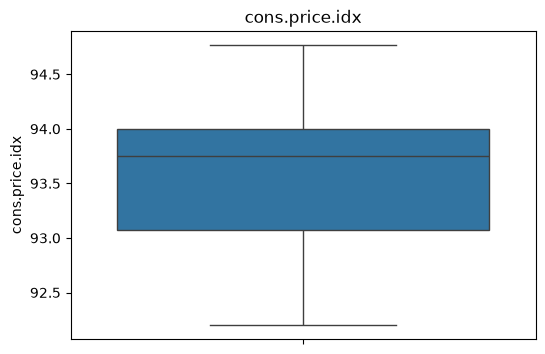

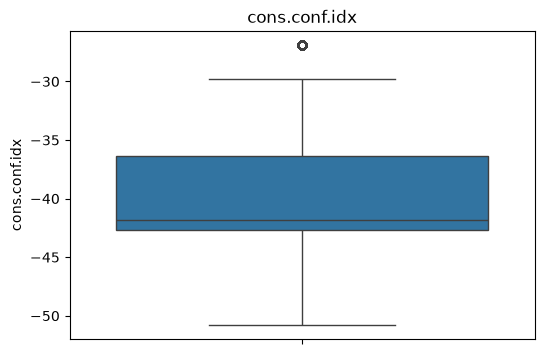

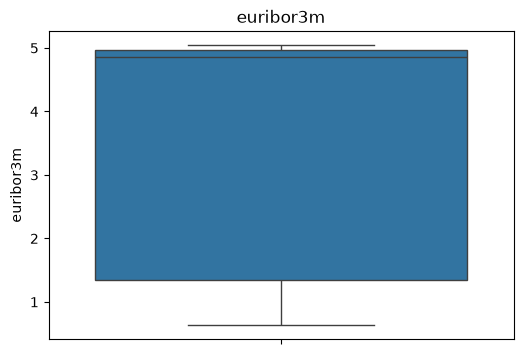

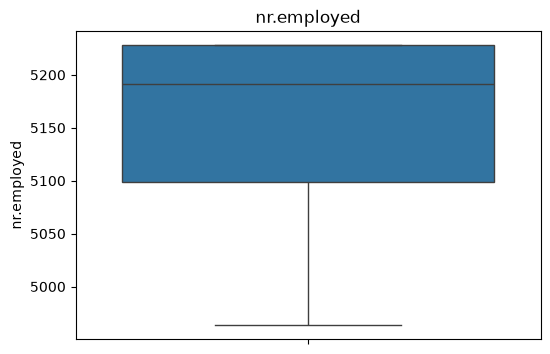

In [17]:
for col in df.select_dtypes(include='number').columns:

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, y=col)
    plt.title(col)
    plt.show()



In [18]:
df.select_dtypes(include='number').columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

In [19]:
for col in df.select_dtypes(include='number').columns:
    print('Column : ',col)

    max_10 = df[col].sort_values(ascending=False).head(10).values
    min_10 = df[col].sort_values(ascending=True).head(10).values
    data = np.array([max_10, min_10]).T
    df_col = pd.DataFrame(data=data,columns=['Max 10 val','Min 10 val'])
    print(df_col)


Column :  age
   Max 10 val  Min 10 val
0        98.0        17.0
1        98.0        17.0
2        95.0        17.0
3        94.0        17.0
4        94.0        17.0
5        92.0        18.0
6        92.0        18.0
7        92.0        18.0
8        92.0        18.0
9        91.0        18.0
Column :  duration
   Max 10 val  Min 10 val
0      4918.0         0.0
1      4199.0         0.0
2      3785.0         0.0
3      3643.0         0.0
4      3631.0         1.0
5      3509.0         1.0
6      3422.0         1.0
7      3366.0         2.0
8      3322.0         3.0
9      3284.0         3.0
Column :  campaign
   Max 10 val  Min 10 val
0        56.0         1.0
1        43.0         1.0
2        43.0         1.0
3        42.0         1.0
4        42.0         1.0
5        41.0         1.0
6        40.0         1.0
7        40.0         1.0
8        39.0         1.0
9        37.0         1.0
Column :  pdays
   Max 10 val  Min 10 val
0       999.0         0.0
1       999.0         

In [20]:
for col in df.select_dtypes(include='number').columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} IQR-flagged outliers | range seen: {df[col].min()} to {df[col].max()}")

age: 476 IQR-flagged outliers | range seen: 17.0 to 98.0
duration: 2963 IQR-flagged outliers | range seen: 0.0 to 4918.0
campaign: 2406 IQR-flagged outliers | range seen: 1.0 to 56.0
pdays: 1515 IQR-flagged outliers | range seen: 0.0 to 999.0
previous: 5633 IQR-flagged outliers | range seen: 0.0 to 7.0
emp.var.rate: 0 IQR-flagged outliers | range seen: -3.4 to 1.4
cons.price.idx: 0 IQR-flagged outliers | range seen: 92.201 to 94.767
cons.conf.idx: 447 IQR-flagged outliers | range seen: -50.8 to -26.9
euribor3m: 0 IQR-flagged outliers | range seen: 0.634 to 5.045
nr.employed: 0 IQR-flagged outliers | range seen: 4963.6 to 5228.1


pdays looks suspicious. -1 and 999 are place holder for never contacted before

In [21]:
(df['pdays'] != 999).sum()

np.int64(1515)

Creating a new col where previously contacted coustmers exist

In [22]:
df['Contacted_before'] = (df['pdays'] != 999).astype(int)

If duration is 0 it means call never happened and its a outlier

In [23]:
(df['duration'] == 0).sum()

np.int64(4)

In [24]:
pd.set_option('display.max_columns', None)

In [25]:
df[df['duration'] == 0]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,Contacted_before
6251,39.0,admin.,married,high.school,no,yes,no,telephone,may,tue,0.0,4.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
23031,59.0,management,married,university.degree,no,yes,no,cellular,aug,tue,0.0,10.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no,0
28063,53.0,blue-collar,divorced,high.school,no,yes,no,cellular,apr,fri,0.0,3.0,999.0,0.0,nonexistent,-1.8,93.075,-47.1,1.479,5099.1,no,0
33015,31.0,blue-collar,married,basic.9y,no,no,no,cellular,may,mon,0.0,2.0,999.0,0.0,nonexistent,-1.8,92.893,-46.2,1.299,5099.1,no,0


In [26]:
len(df)

41196

Since the 'duration' col tells for how much the calls last after the call has been made. It doesn't offer much predictive power to the model

predicting the outcome from information you wouldn't actually have before making the call

In [27]:
df.drop(columns=['duration'],inplace=True)

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 41196 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               41196 non-null  float64
 1   job               41196 non-null  str    
 2   marital           41196 non-null  str    
 3   education         41196 non-null  str    
 4   default           41196 non-null  str    
 5   housing           41196 non-null  str    
 6   loan              41196 non-null  str    
 7   contact           41196 non-null  str    
 8   month             41196 non-null  str    
 9   day_of_week       41196 non-null  str    
 10  campaign          41196 non-null  float64
 11  pdays             41196 non-null  float64
 12  previous          41196 non-null  float64
 13  poutcome          41196 non-null  str    
 14  emp.var.rate      41196 non-null  float64
 15  cons.price.idx    41196 non-null  float64
 16  cons.conf.idx     41196 non-null  float64
 17  euribor3m

# Summary

no true outliers found, one column dropped for target leakage, one column re-engineered because it used a placeholder sentinel value

Checking on the Target column

In [29]:
df['y'].value_counts(normalize=True) * 100

y
no     88.736771
yes    11.263229
Name: proportion, dtype: float64

# Resetting the index for a clean df

In [30]:
df.reset_index(drop=True)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,Contacted_before
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1.0,999.0,0.0,nonexistent,1.1,93.994000,-36.4,4.857,5191.0,no,0
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,1.0,999.0,0.0,nonexistent,1.1,93.994000,-36.4,4.857,5191.0,no,0
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,1.0,999.0,0.0,nonexistent,1.1,93.994000,-36.4,4.857,5191.0,no,0
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,1.0,999.0,0.0,nonexistent,1.1,93.994000,-36.4,4.857,5191.0,no,0
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,1.0,999.0,0.0,nonexistent,1.1,93.994000,-36.4,4.857,5191.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41191,94.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,3.0,999.0,1.0,failure,-1.1,94.767000,-50.8,1.028,4963.6,no,0
41192,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,3.0,999.0,1.0,failure,-1.1,94.767000,-50.8,1.028,4963.6,no,0
41193,74.0,admin.,married,professional.course,no,yes,no,cellular,nov,fri,3.0,999.0,1.0,failure,-1.1,94.767000,-50.8,1.028,4963.6,no,0
41194,74.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,3.0,999.0,1.0,failure,-1.1,94.767000,-50.8,1.028,4963.6,no,0


# Creating a pipeline

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import  train_test_split,StratifiedKFold
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix

In [35]:
X = df.drop('y',axis=1)
y = df['y']

In [36]:
le = LabelEncoder()
y = le.fit_transform(y)

In [46]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(41196,))

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [38]:
exclude_col = ['default']

numericals_col = X.select_dtypes(include='number').columns
categorical_col = X.select_dtypes(include=['object', 'str']).columns.difference(exclude_col)

# preprocessing = Pipeline()
num_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='mean')),
    ('scale',StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder())
])

def_pipeline = Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encode',OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ('num_col',num_pipeline,numericals_col),
    ('cat_col',cat_pipeline,categorical_col),
    ('def_col',def_pipeline,exclude_col)
])

#multiple models


model1 = Pipeline([
    ('preprocessing',preprocessor),
    ('clf',LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000))
])

model2 = Pipeline([
    ('preprocessing',preprocessor),
    ('clf',RandomForestClassifier(max_depth=5,n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1))
])

model3 = Pipeline([
    ('preprocessing',preprocessor),
    ('clf',GradientBoostingClassifier(n_estimators=100,max_depth=5,random_state=42,learning_rate=5e-3))
])

model4 = Pipeline([
    ('preprocessing',preprocessor),
    ('clf',AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),random_state=42,learning_rate=5e-3))
])

weight_ratio = (y_train == 0).sum()/(y_train == 1).sum()

model5 = Pipeline([
    ('preprocessing',preprocessor),
    ('clf',XGBClassifier(
            scale_pos_weight = weight_ratio ,
            n_estimators = 300,
            learning_rate = 0.05,
            max_depth = 3,
            subsample = 0.8,
            reg_alpha = 1,
            reg_lambda = 1,
            colsample_bytree = 0.8,
            random_state = 34,
            objective = 'binary:logistic',
            eval_metric = 'logloss'
        )
    )
])


Precision : Of all the predicted positives how many are True positives : TP/TP+FP

Recall : Of all the actual positives how many many True positives  : TP/TP+FN

In [39]:
# models = [model1,model2]
models = [model1,model2,model3,model4,model5]
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)


records = []

for i,model in enumerate(models ,start=1):
    score = []

    for train_idx, val_idx in skf.split(X_train,y_train):
        X_train_skf = X_train.iloc[train_idx]
        y_train_skf = y_train[train_idx]

        X_val_skf = X_train.iloc[val_idx]
        y_val_skf = y_train[val_idx]

        model.fit(X_train_skf,y_train_skf)
        y_proba = model.predict_proba(X_val_skf)[:,1]
        score.append(roc_auc_score(y_val_skf,y_proba))

    records.append({'model': model, 'model_name': type(model.named_steps['clf']).__name__, 'score': np.mean(score)})

df_score =  pd.DataFrame(data=records)



In [80]:
best_model = df_score[:2]
best_model

,model,model_name,score
0,"(ColumnTransformer(transformers=[('num_col',\n...",LogisticRegression,0.790303
1,"(ColumnTransformer(transformers=[('num_col',\n...",RandomForestClassifier,0.790970


In [ ]:
best_row['model'].fit(X_train,y_train)
y_pred = best_row['model'].predict(X_test)
y_proba = best_row['model'].predict_proba(X_test)[:,0]


print(f"---best model is {best_row['model_name']} ---")

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba),4))

<class 'numpy.ndarray'>
(8240,)


In [42]:
import joblib

joblib.dump(best_row['model'],'../models/model_pipeline.joblib')

['../models/model_pipeline.joblib']

In [43]:
joblib.dump(le,'../models/le_encoder.joblib')

['../models/le_encoder.joblib']

In [44]:
import os

print(os.getcwd())

d:\Desktop\PROJECTS\project1\notebooks
